# Supervised Learning Demo II: Logistic Regression

<br>

In this notebook we tackle a **classification** problem — predicting whether a passenger **survived** the Titanic disaster (yes or no).

Along the way we'll also handle **missing data** and encode categorical variables before training.

**What you'll learn:**
- Basic data cleaning: dropping missing values and encoding categoricals
- How Logistic Regression works for binary classification
- How to evaluate a classifier with accuracy and a confusion matrix

<br>

---

## 1. The Problem

The **Titanic** sank on April 15, 1912. Of the ~2,200 people on board, only ~710 survived.

We have data on **891 passengers**. Our goal: **predict whether a passenger survived** based on features like ticket class, sex, and fare.

This is a **binary classification** problem — the target variable `survived` is either `0` (did not survive) or `1` (survived).

| Column | Description |
|--------|-------------|
| `survived` | Target — 0 = No, 1 = Yes |
| `pclass` | Ticket class: 1 = First, 2 = Second, 3 = Third |
| `sex` | Passenger sex |
| `age` | Age in years |
| `sibsp` | # of siblings / spouses aboard |
| `parch` | # of parents / children aboard |
| `fare` | Passenger fare |
| `embarked` | Port of embarkation (C, Q, S) |

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('titanic')
df.head()

---

## 2. Exploratory Data Analysis (EDA)

Before building a model, let's understand the data — its shape, data types, and how the target variable is distributed.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Target Distribution

Let's check how balanced our classes are. An imbalanced dataset can make accuracy a misleading metric — we'll come back to this in the evaluation section.

survived
0    549
1    342
Name: count, dtype: int64

survived
0    0.62
1    0.38
Name: proportion, dtype: float64


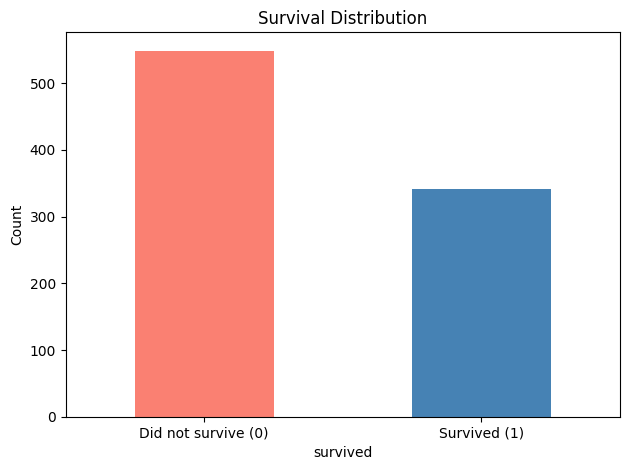

In [ ]:
print(df['survived'].value_counts())
print()
print(df['survived'].value_counts(normalize=True).round(2))

df['survived'].value_counts().plot(kind='bar', color=['salmon', 'steelblue'])
plt.xticks([0, 1], ['Did not survive (0)', 'Survived (1)'], rotation=0)
plt.ylabel('Count')
plt.title('Survival Distribution')
plt.tight_layout()
plt.show()

**Observation:** About **62% did not survive** and **38% survived** — the classes are imbalanced. We'll keep this in mind when evaluating the model.

---

## 3. Data Cleaning

Real-world data is messy. `sklearn` models **cannot handle missing values** — we need to clean the data before training.

Let's check which columns have missing values.

In [ ]:
df.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
class            0
who              0
adult_male       0
alive            0
alone            0
dtype: int64

Four columns have missing values:

| Column | Missing | Strategy |
|--------|---------|----------|
| `deck` | 688 (77%) | Drop column |
| `age` | 177 (20%) | Drop column |
| `embark_town` | 2 | Drop column |
| `embarked` | 2 | Drop column |

**Strategy:** We'll drop any column that has missing values. In practice, you'd often *impute* them (fill with the median, mean, or a model) — but dropping is the simplest starting point.

In [ ]:
# Drop all columns that contain any missing values
df = df.dropna(axis=1)

print("Remaining columns:", df.columns.tolist())
print("\nAny missing values left?", df.isnull().sum().sum())

Remaining columns: ['survived', 'pclass', 'sex', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male', 'alive', 'alone']

Any missing values left? 0


### Drop Redundant and Leakage Columns

Some remaining columns need to be removed for different reasons:

| Column | Reason |
|--------|--------|
| `alive` | ⚠️ **Data leakage** — same as `survived` but encoded as `'yes'`/`'no'` |
| `class` | Redundant — same info as `pclass` but as a string |
| `who` | Redundant — derived from `sex` |
| `adult_male` | Redundant — derived from `sex` |

> **Data leakage** means including information that directly encodes the target or that wouldn't be available at prediction time. It inflates model performance and makes it useless in the real world.

In [ ]:
df = df.drop(columns=['alive', 'class', 'who', 'adult_male'])

print("Columns after dropping:", df.columns.tolist())

Columns after dropping: ['survived', 'pclass', 'sex', 'sibsp', 'parch', 'fare', 'alone']


### Encode Categorical Variables

`sklearn` requires **numeric inputs**. The `sex` column contains strings (`'male'` / `'female'`). We convert it with `pd.get_dummies()`.

With `drop_first=True`, it removes one redundant column — so `sex` becomes a single column `sex_male`:
- `1` = male
- `0` = female

In [ ]:
df = pd.get_dummies(df, columns=['sex'], drop_first=True)

df.head()

,survived,pclass,sibsp,parch,fare,alone,sex_male
0,0,3,1,0,7.2500,False,True
1,1,1,1,0,71.2833,False,False
2,1,3,0,0,7.9250,True,False
3,1,1,1,0,53.1000,False,False
4,0,3,0,0,8.0500,True,True


✅ Data is now clean: no missing values, no leakage, all numeric. Final shape: **891 rows × 7 columns**.

---

## 4. Data Splitting

Same approach as Demo I: split into **training** (80%) and **test** (20%) sets.

One addition here: we use `stratify=y` to ensure both splits preserve the original class ratio (~62% / 38%). This is important when the target is imbalanced.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['survived'])
y = df['survived']

print("Features:", X.columns.tolist())
print("\nTarget distribution:\n", y.value_counts(normalize=True).round(2))

Features: ['pclass', 'sibsp', 'parch', 'fare', 'alone', 'sex_male']

Target distribution:
 survived
0    0.62
1    0.38
Name: proportion, dtype: float64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} rows")
print(f"Test size:  {X_test.shape[0]} rows")

Train size: 712 rows
Test size:  179 rows


---

## 5. Feature Selection

Not all features are equally useful. **Correlated features** carry redundant information — including both can add noise without adding signal.

We'll use a **correlation matrix** to identify and remove them.

In [ ]:
X_train.corr().round(2)

,pclass,sibsp,parch,fare,alone,sex_male
pclass,1.00,0.10,0.04,-0.56,0.13,0.15
sibsp,0.10,1.00,0.39,0.13,-0.58,-0.10
parch,0.04,0.39,1.00,0.18,-0.58,-0.26
fare,-0.56,0.13,0.18,1.00,-0.25,-0.21
alone,0.13,-0.58,-0.58,-0.25,1.00,0.32
sex_male,0.15,-0.10,-0.26,-0.21,0.32,1.00


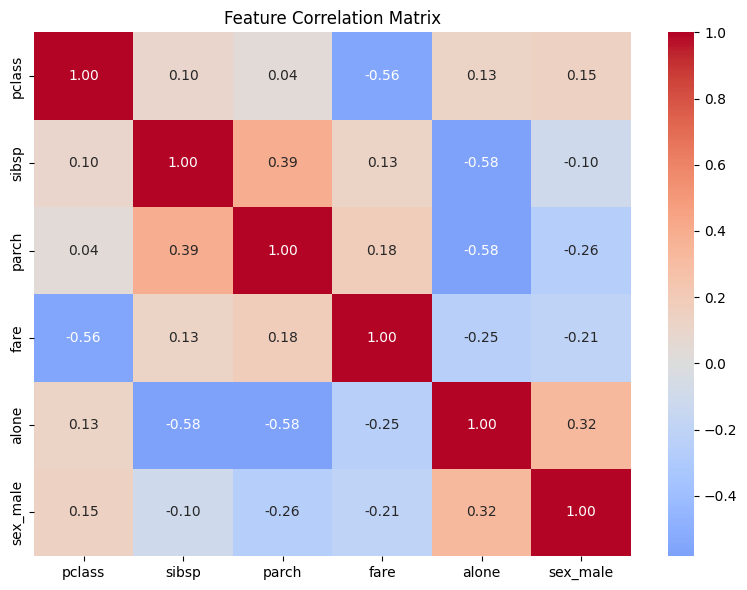

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(X_train.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

**Observation:** `alone` is notably correlated with both `sibsp` (r ≈ -0.6) and `parch` (r ≈ -0.4). This makes sense — `alone` is `True` when `sibsp == 0` AND `parch == 0`. It's a derived feature that adds no new information.

We'll drop `alone` to reduce redundancy.

In [ ]:
X_train = X_train.drop(columns=['alone'])
X_test = X_test.drop(columns=['alone'])

print("Final features:", X_train.columns.tolist())

Final features: ['pclass', 'sibsp', 'parch', 'fare', 'sex_male']


---

## 6. Model Training

### How Logistic Regression Works

Despite its name, Logistic Regression is a **classification** algorithm. Instead of predicting a continuous value, it predicts the **probability** that an input belongs to class 1 (survived).

It uses the **sigmoid function** to squash any value into the range [0, 1]:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

A threshold of **0.5** is then applied:
- Probability ≥ 0.5 → predict **survived (1)**
- Probability < 0.5 → predict **did not survive (0)**

<br>

![](../_images/logistic-regression-i.png)

<br>

![](../_images/logistic-regression-ii.png)

(Image source: [Medium](https://medium.com/@jramiroz98/logistic-regression-e5d784ba7b99))

<br>

Logistic regression first computes a weighted sum of the input features (like linear regression), then applies a sigmoid function to that result to convert it into a probability between 0 and 1:

![](../_images/logistic-regression-iii.jpg)

(Image source: [datahacker](https://datahacker.rs/004-machine-learning-logistic-regression-model/))

<br>
<br>



In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model trained ✅")

Model trained ✅


Same 2-line pattern as Demo I: create the model → call `.fit()`. The `max_iter` parameter gives the solver enough iterations to converge on this dataset.

---

## 7. Model Evaluation

For **regression** we used R². For **classification**, two common tools are:
- **Accuracy** — fraction of predictions that were correct
- **Confusion Matrix** — a breakdown of correct and incorrect predictions by class

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)

### Accuracy

$$\text{Accuracy} = \frac{\text{Correct predictions}}{\text{Total predictions}}$$

Simple and intuitive, but it can be misleading with imbalanced classes — a model that always predicts "did not survive" would get 62% accuracy without learning anything useful.

In [ ]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2%}")

Accuracy: 81.01%


### Confusion Matrix

A confusion matrix shows **where** the model makes mistakes:

|  | Predicted: 0 | Predicted: 1 |
|--|-------------|-------------|
| **Actual: 0** | True Negative (TN) ✅ | False Positive (FP) ❌ |
| **Actual: 1** | False Negative (FN) ❌ | True Positive (TP) ✅ |

- **TN** — correctly predicted "did not survive"
- **TP** — correctly predicted "survived"
- **FP** — predicted "survived" but they didn't ❌
- **FN** — predicted "did not survive" but they did ❌

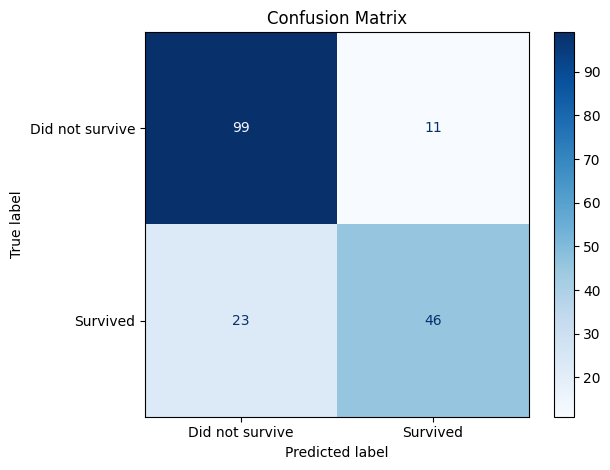

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred),
    display_labels=['Did not survive', 'Survived']
)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

**Interpretation:**
- The model is reasonably good at identifying passengers who **did not survive** (large TN count).
- It misses more survivors than non-survivors — partly because survivors are the minority class, and partly because we dropped `age`, which is a meaningful predictor of survival.

This is a known trade-off when doing simple data cleaning. Metrics like **precision**, **recall**, and **F1-score** give a fuller picture for imbalanced problems — but that's a topic for another session! 🚀